In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb
import h5py

import sys
sys.path.append('../../../src/')
from build_model import fpn_resnet50_classification
from trainer import Trainer
from dataset_functions import split_train_valid, list_to_dict, viz_dataloader, hdf5_dataset
from visualization_functions import show_images

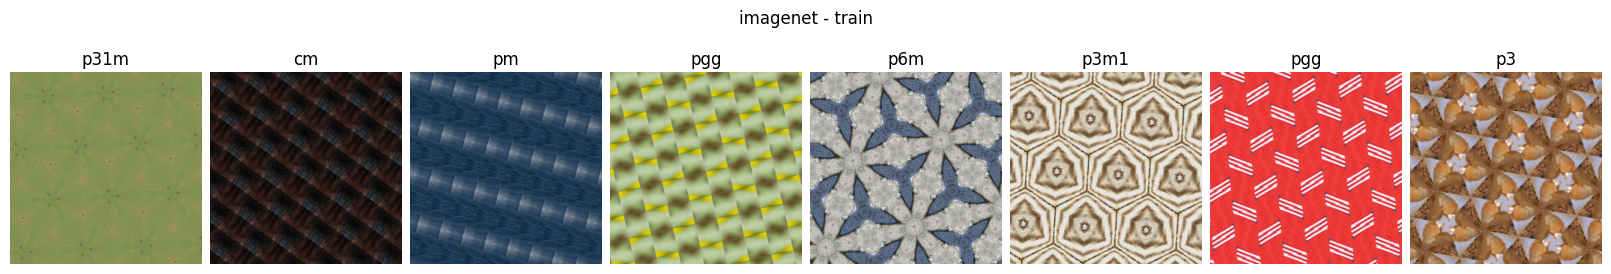

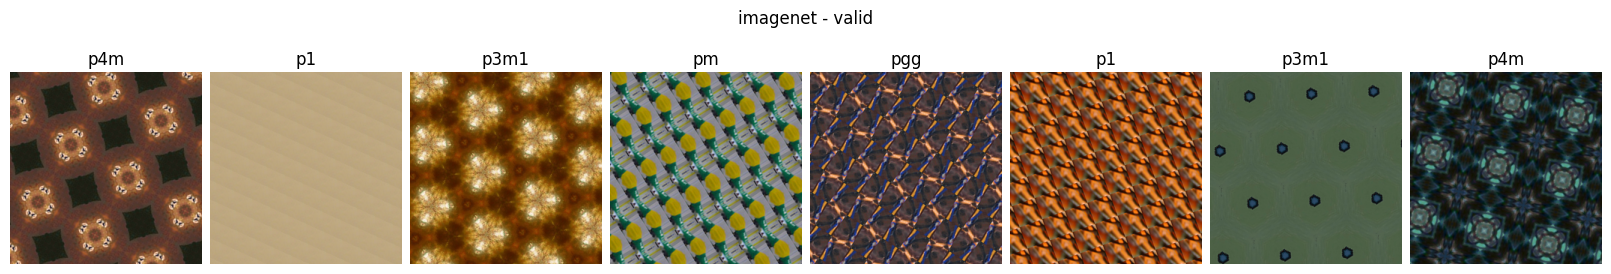

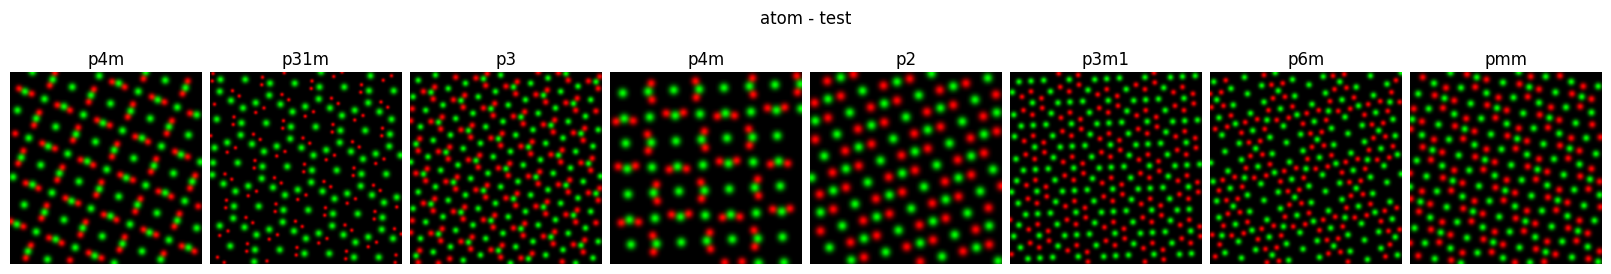

In [2]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# imagenet
train_ds = hdf5_dataset('../../../datasets/imagenet_v4_rot_10m_train_unchunked.h5', folder='train', transform=transforms.ToTensor())
train_dl = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=6)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')

# imagenet
valid_ds = hdf5_dataset('../../../datasets/imagenet_v4_rot_2m_valid_unchunked.h5', folder='valid', transform=transforms.ToTensor())
valid_dl = DataLoader(valid_ds, batch_size=256, shuffle=False, num_workers=6)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

# atom
test_ds = hdf5_dataset('../../../datasets/atom_v4_rot_2m_unchunked.h5', folder='test', transform=transforms.ToTensor())
test_dl = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=6)
viz_dataloader(test_dl, label_converter=label_converter, title='atom - test')

In [3]:
model = fpn_resnet50_classification(in_channels=3, n_classes=17)
print(model)
outputs = model.fpn(torch.randn(2,3,256,256))
for o in outputs:
    print(o.shape)
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)

fpn_resnet50_classification(
  (fpn): feature_pyramid_network(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (downsample): Sequential(
          (0

/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torch/nn/functional.py:3769: UserWarning: nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.
  warnings.warn("nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.")


# train

In [4]:
wandb.login()
config = {
    'dataset': '10 million datasets',
    'model': 'fpn_resnet50_yichen',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = '01182024-benchmark-fpn_resnet50-v4_10m'

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, group='benchmark', save_code=True, config=config)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [5]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
lr = 1e-3
max_epochs = 20

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=max_epochs, max_lr=lr, steps_per_epoch=len(train_dl))
trainer = Trainer(model, train_dl, valid_dl, test_dl, loss_func, optimizer, scheduler, gpu_id=device, save_every=5, model_path=None)

In [6]:
trainer.train(max_epochs=max_epochs, tracking=True)

Epoch: 1/20


  0%|          | 0/39063 [00:00<?, ?it/s]/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torch/nn/functional.py:3769: UserWarning: nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.
  warnings.warn("nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.")
  0%|          | 100/39063 [00:50<6:11:22,  1.75it/s]/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torch/nn/functional.py:3769: UserWarning: nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.
  warnings.warn("nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.")
100%|██████████| 39063/39063 [5:20:37<00:00,  2.03it/s]  

train Loss: 0.2642, train Accuracy: 91.60%



100%|██████████| 7813/7813 [32:14<00:00,  4.04it/s]

valid Loss: 0.0479, valid Accuracy: 98.41%


...

train Loss: 0.0011, train Accuracy: 99.96%



100%|██████████| 7813/7813 [33:54<00:00,  3.84it/s]

valid Loss: 0.0030, valid Accuracy: 99.92%



100%|██████████| 7940/7940 [34:16<00:00,  3.86it/s]

test Loss: 5.7419, test Accuracy: 57.26%


In [9]:
device = torch.device('cuda:0')
lr = 1e-3
start = 0
epochs = 20

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl,
                       epochs=epochs, start=start, scheduler=scheduler, 
                       model_dir='../../../saved_models/', tracking=True)

Epoch: 1/20


100%|██████████| 43479/43479 [5:22:41<00:00,  2.25it/s]  


Training: Loss: 0.4934, Accuracy: 83.5459%, Time: 322.6925mins


100%|██████████| 8696/8696 [25:57<00:00,  5.58it/s]


Validation : Loss : 0.0767, Accuracy: 97.5331%, Time: 25.97mins


...

100%|██████████| 8696/8696 [26:07<00:00,  5.55it/s]


Validation : Loss : 0.0037, Accuracy: 99.9144%, Time: 26.13mins


100%|██████████| 1985/1985 [27:08<00:00,  1.22it/s]


Validation : Loss : 5.8107, Accuracy: 57.9332%, Time: 27.15mins
Error in callback <function _WandbInit._pause_backend at 0x7fdbd998d550> (for post_run_cell):


FileNotFoundError: [Errno 2] No such file or directory: '/scratch/yichen/notebooks/1.Symmetry_Identification/symmetry_paper/1.benchmark/wandb/run-20230607_115744-05312023-benchmark-resnet50_from_scratch-v4_10m/tmp/code/05312023-benchmark-resnet50_from_scratch-dataset_v4-train.ipynb'

# analyze

In [8]:
model = torch.load('/scratch/yichen/models/05312023-benchmark-resnet50_from_scratch-v4_10m-epoch-19.pt')

NAME = 'benchmark-resnet50_from_scratch-v4_10m-05312023'
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                    'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']                  

In [9]:
device = torch.device('cuda:2')

cm = confusion_matrix(model, train_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-train_cm.npy', cm)

100%|██████████| 43479/43479 [2:17:30<00:00,  5.27it/s]  


Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,588308.0,588239.0,588239.0,588233.0,588232.0,588231.0,588236.0,588232.0,588239.0,588237.0,588238.0,588239.0,588239.0,588224.0,588239.0,588238.0,588237.0


Accuracy for these batches: 0.9996354029167767


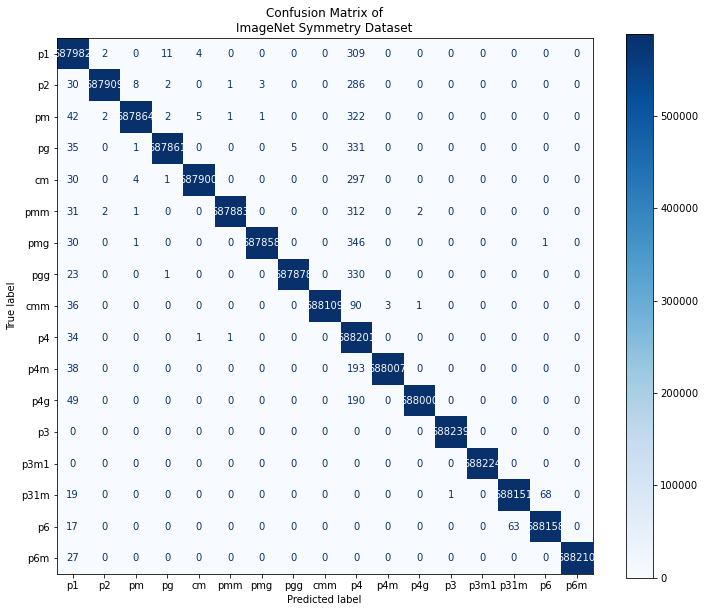

In [10]:
# cm = np.load('11172021-benchmark_atom-fpn_spatial-transfer_learning-train.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nImageNet Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [11]:
cm = confusion_matrix(model, valid_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-valid_cm.npy', cm)

100%|██████████| 8696/8696 [27:55<00:00,  5.19it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,117670.0,117647.0,117647.0,117647.0,117646.0,117646.0,117648.0,117647.0,117647.0,117646.0,117647.0,117648.0,117647.0,117645.0,117645.0,117646.0,117647.0


Accuracy for these batches: 0.9991540067679459


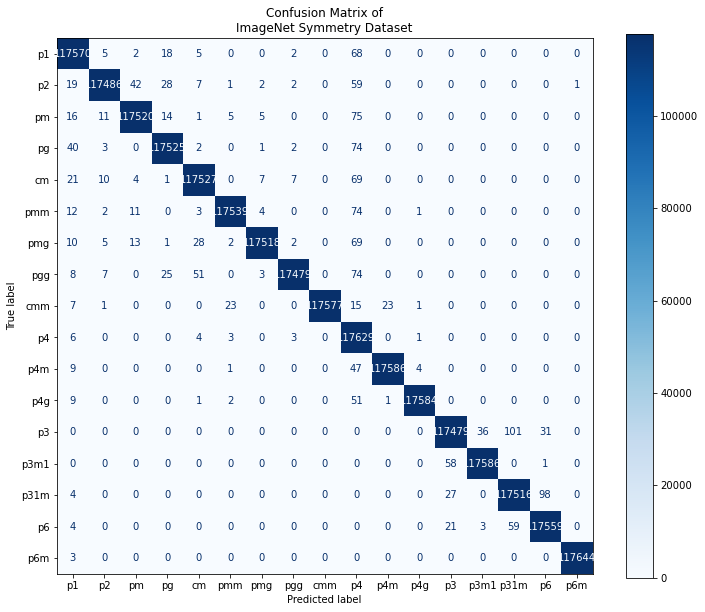

In [12]:
# cm = np.load('11172021-benchmark_imagenet-fpn_spatial-transfer_learning-valid.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nImageNet Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [13]:
cm = confusion_matrix(model, test_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-test_cm.npy', cm)

100%|██████████| 1985/1985 [29:26<00:00,  1.12it/s]


Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,270351.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0


Accuracy for these batches: 0.5805782531969523


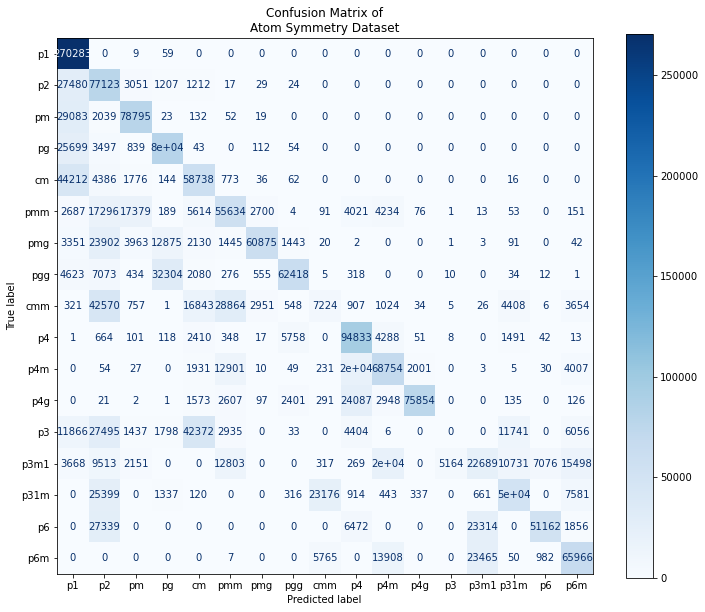

In [14]:
# cm = np.load('05232022-benchmark-resnet50_from_scratch-dataset_v3-test.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nAtom Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')